# 醫療保險費用預測（Medical Insurance Charge Prediction）
## AI Applications in Finance — 期末專題（2026）

**任務類型：** 監督式**迴歸（Regression）**，預測每位投保人的年度醫療費用 `charges`。

> **情境設定：** 假設你是健康保險公司的初階資料科學家。主管交付一份資料，希望你建立一個
> 可解釋、可重現的模型來預測投保人的年度醫療費用，用於（1）依風險公平訂定保費、
> （2）及早辨識高成本族群以進行健康管理。

本 Notebook 完全可重現：以 `medical_insurance.xlsx` 由上到下執行，即可重現報告中的所有數字與圖表。

依作業要求涵蓋五個階段：
1. 問題定義與探索式資料分析（EDA）
2. 資料前處理與特徵工程
3. 模型選擇與理由說明
4. 訓練、調參與評估
5. 結果詮釋與商業結論


### 環境與套件
下方匯入所需套件，並固定亂數種子（`RANDOM_STATE = 42`）以確保結果可重現。

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                 # 固定亂數種子，確保可重現
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = {"no": "#4C72B0", "yes": "#DD8452"}   # 吸菸 vs 不吸菸 配色

## 階段 1 — 問題定義與探索式資料分析（EDA）

**商業問題（用自己的話重述）：** 給定投保人的人口與健康屬性
（`age` 年齡、`sex` 性別、`bmi` 身體質量指數、`children` 子女數、`smoker` 是否吸菸、`region` 地區），
預測其**年度醫療費用（USD）**。準確的費用預測可支援風險導向的保費訂價，並提早辨識高成本投保人。

**任務類型判斷：** 目標變數 `charges` 為連續值 → 屬於**監督式迴歸**（非分類、非分群）。


先載入資料,檢視大小、欄位型態、缺失值與重複列。

> **可攜性說明:** 資料同時**內嵌於本 Notebook**(壓縮編碼)。下方會先嘗試讀取同資料夾的
> `medical_insurance.xlsx`;若找不到(例如在 Google Colab 直接上傳 Notebook),會自動改用
> 內嵌資料 —— 因此**不需手動上傳資料檔即可一鍵全部執行**,且資料內容完全相同。


In [2]:
# 內嵌資料(gzip + base64 編碼的原始 CSV);找不到 xlsx 時自動使用,確保到處可重現
import io, gzip, base64
_EMBEDDED_DATA_B64 = "..."

try:
    df = pd.read_excel("medical_insurance.xlsx")          # 優先讀取本機資料檔
    print("資料來源:本機 medical_insurance.xlsx")
except FileNotFoundError:
    df = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(_EMBEDDED_DATA_B64))))
    print("資料來源:Notebook 內嵌資料(找不到 xlsx,自動切換)")

print("資料維度 Shape:", df.shape)
display(df.head())
print("\n欄位型態 Dtypes:\n", df.dtypes)
print("\n缺失值 Missing:\n", df.isna().sum())
print("\n完全重複的列數:", df.duplicated().sum(),
      "｜ 去重後唯一列數:", len(df.drop_duplicates()))
df.describe().round(2)

資料來源:本機 medical_insurance.xlsx
資料維度 Shape: (2772, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



欄位型態 Dtypes:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

缺失值 Missing:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

完全重複的列數: 1435 ｜ 去重後唯一列數: 1337


,age,bmi,children,charges
count,2772.00,2772.00,2772.00,2772.00
mean,39.11,30.70,1.10,13261.37
std,14.08,6.13,1.21,12151.77
min,18.00,15.96,0.00,1121.87
25%,26.00,26.22,0.00,4687.80
50%,39.00,30.45,1.00,9333.01
75%,51.00,34.77,2.00,16577.78
max,64.00,53.13,5.00,63770.43


**EDA 觀察重點**
- **無缺失值**；共 6 個特徵 + 1 個目標變數。
- **嚴重重複**：2,772 列去重後僅剩 **1,337 列** —— 這份檔案其實是經典的 1,338 列 Kaggle
  資料**重複約 2 倍**。這是一個**資料外洩（data leakage）陷阱**，會在階段 2 處理。
- `charges` 明顯**右偏**（偏度 ≈ 1.5），取對數後接近對稱。


### 1.1 重複結構分析（為去重決策佐證）

EDA 發現 2,772 列去重後只剩 1,337 列。為了佐證「這是被複製的資料、必須去重」,
而非偶然出現相同的人,進行以下分析:

1. **每個唯一列出現幾次** —— 若是程式複製,會呈現整齊的倍數(各 2 份、4 份)。
2. **連續變數是否完全相同** —— `charges` 精確到小數點下 5 位,兩個不同的人費用全等的機率近乎 0。


In [3]:
# (1) 每個唯一列出現次數的分布
dup_profile = df.value_counts().value_counts().sort_index()
dup_profile = dup_profile.rename_axis("出現次數").reset_index(name="有幾種唯一列")
display(dup_profile)
print("驗證:", " + ".join(f"{r['有幾種唯一列']}x{r['出現次數']}" for _, r in dup_profile.iterrows()),
      "=", int((dup_profile["出現次數"]*dup_profile["有幾種唯一列"]).sum()), "= 原始列數")

# (2) 以第 1 列為例,找出與它「七欄完全相同」的所有列
row0 = df.iloc[0]
same = df.index[(df == row0).all(axis=1)].tolist()
print("\n與第 1 列完全相同的列 (1-based):", [i+1 for i in same])
display(df.loc[same])
print("結論:連 charges 都精準到小數第 5 位相同 -> 屬於『完全重複(exact duplicate)』,"
      "切分前去除可避免訓練/測試資料外洩。")

,出現次數,有幾種唯一列
0,2,1288
1,4,49


驗證: 1288x2 + 49x4 = 2772 = 原始列數

與第 1 列完全相同的列 (1-based): [1, 1387]


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924
1386,19,female,27.9,0,yes,southwest,16884.924


結論:連 charges 都精準到小數第 5 位相同 -> 屬於『完全重複(exact duplicate)』,切分前去除可避免訓練/測試資料外洩。


**圖 1：目標變數分布（原始 vs 取對數）** —— 確認右偏特性。

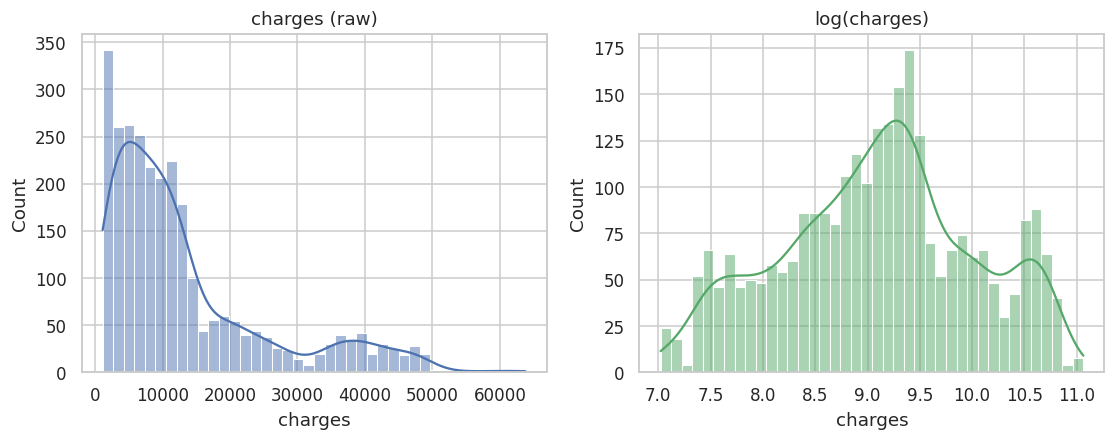

偏度 skew raw = 1.511 ｜ skew log = -0.089


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], bins=40, kde=True, color="#4C72B0", ax=ax[0]); ax[0].set_title("charges (raw)")
sns.histplot(np.log(df["charges"]), bins=40, kde=True, color="#55A868", ax=ax[1]); ax[1].set_title("log(charges)")
plt.show()
print("偏度 skew raw =", round(df['charges'].skew(),3), "｜ skew log =", round(np.log(df['charges']).skew(),3))

**圖 2：相關係數矩陣** —— 找出與費用最相關的變數。

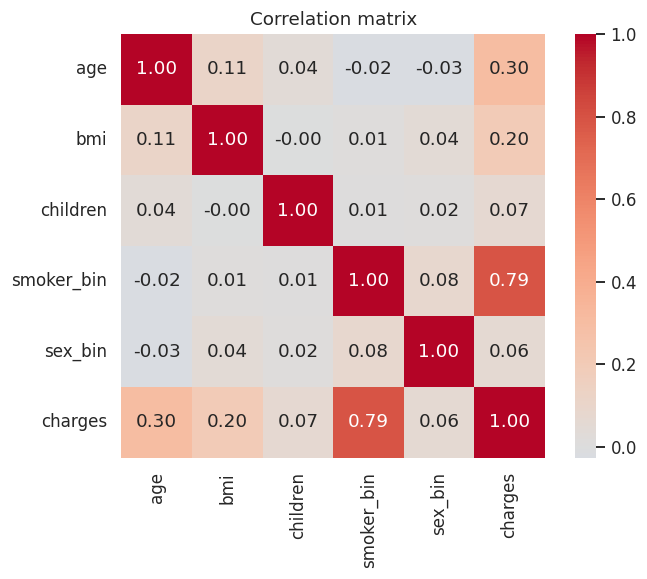

各變數與 charges 的相關係數（由大到小）:
smoker_bin    0.789
age           0.299
bmi           0.200
children      0.066
sex_bin       0.063
Name: charges, dtype: float64


In [5]:
enc = df.copy()
enc["smoker_bin"] = (enc["smoker"]=="yes").astype(int)
enc["sex_bin"] = (enc["sex"]=="male").astype(int)
corr = enc[["age","bmi","children","smoker_bin","sex_bin","charges"]].corr()
plt.figure(figsize=(7,5)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix"); plt.show()
print("各變數與 charges 的相關係數（由大到小）:")
print(corr["charges"].drop("charges").sort_values(ascending=False).round(3))

**圖 3 / 圖 4：費用 vs 年齡、費用 vs BMI（依吸菸與否上色）** —— 觀察成本分群。

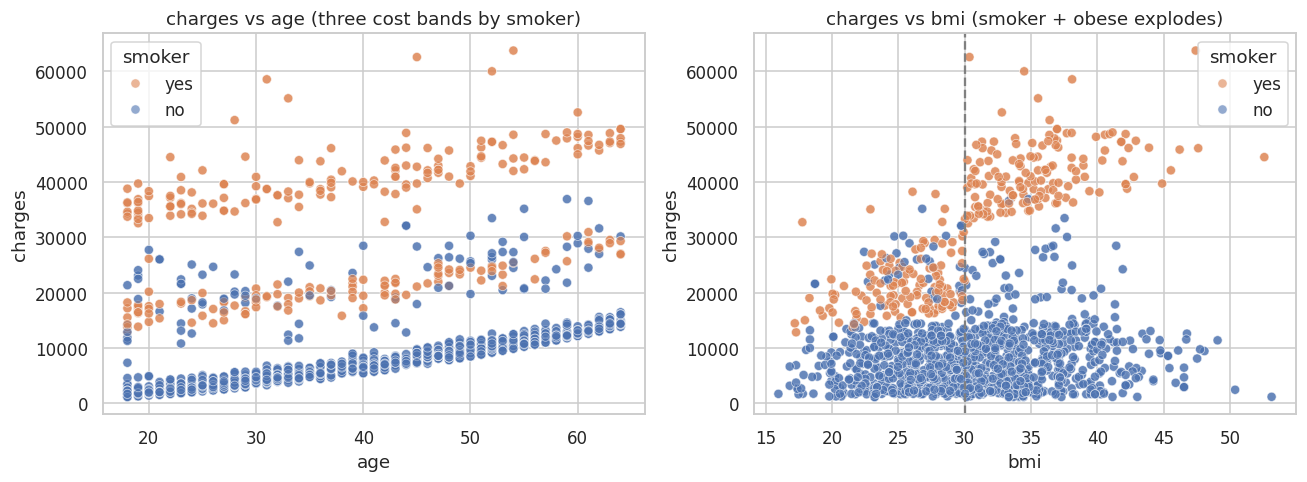

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", palette=PALETTE, alpha=.6, ax=ax[0])
ax[0].set_title("charges vs age (three cost bands by smoker)")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette=PALETTE, alpha=.6, ax=ax[1])
ax[1].axvline(30, ls="--", c="grey"); ax[1].set_title("charges vs bmi (smoker + obese explodes)")
plt.show()

**關鍵關係：**
- `smoker`（是否吸菸）是最主要的驅動因子（相關係數 ≈ **0.79**），遠高於其他變數。
- 吸菸者又依 BMin 分成兩群：**吸菸且 BMI ≥ 30（肥胖）** 者費用爆增。
- 年齡帶來穩定且略為加速的費用上升。
- 這些**交互關係**啟發了階段 2 的特徵工程（`smoker_obese`、`age²`）。


## 階段 2 — 資料前處理與特徵工程

| 決策項目 | 做法 | 理由 |
|---|---|---|
| 缺失值 | 無需處理 | 資料完整無缺失 |
| **去除重複** | 切分前先去除完全重複列 | 防止相同列同時落在訓練/測試集造成外洩；2,772 → 1,337 |
| 類別編碼 | One-Hot（`drop="first"`） | `sex / smoker / region` 為低基數名目變數，避免虛擬變數陷阱 |
| 數值標準化 | StandardScaler | 線性模型需要（係數可比較）；對樹模型無害 |
| 訓練/測試切分 | 80 / 20 隨機，種子 42 | 無時間順序 → 隨機切分合適；連續目標不需分層 |

**特徵工程（作業要求至少一個非平凡特徵，並說明理由）：**
- **`smoker_obese` = 吸菸 ×（BMI ≥ 30）** —— **交互項**，明確隔離出 EDA 找到的最高成本族群（最有價值的特徵）。
- **`age2` = 年齡²** —— 醫療費用隨年齡加速上升，二次項讓即使是線性模型也能捕捉此曲率。
- **`obese` = BMI ≥ 30** —— 臨床肥胖旗標。


In [7]:
# 去除重複（切分前進行，避免資料外洩）
df = df.drop_duplicates().reset_index(drop=True)
print("去重後維度:", df.shape)

# 特徵工程
df["obese"]        = (df["bmi"] >= 30).astype(int)            # 肥胖旗標
df["smoker_bin"]   = (df["smoker"] == "yes").astype(int)
df["smoker_obese"] = df["smoker_bin"] * df["obese"]           # 吸菸 × 肥胖 交互項
df["age2"]         = df["age"] ** 2                           # 年齡非線性效果
print("各 smoker_obese 群組的平均費用:\n", df.groupby("smoker_obese")["charges"].mean().round(0))

# 定義特徵與目標
numeric     = ["age","bmi","children","age2","smoker_obese","obese"]
categorical = ["sex","smoker","region"]
X = df[numeric + categorical]; y = df["charges"]

# 80/20 隨機切分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print("訓練集:", X_train.shape, "｜ 測試集:", X_test.shape)

# 前處理器：數值標準化 + 類別 One-Hot
pre = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
])

去重後維度: (1337, 7)
各 smoker_obese 群組的平均費用:
 smoker_obese
0     9839.0
1    41558.0
Name: charges, dtype: float64
訓練集: (1069, 9) ｜ 測試集: (268, 9)


## 階段 3 — 模型選擇與理由說明

**基準模型 — 線性迴歸（Linear Regression）**
費用隨年齡大致呈線性、並依吸菸與否大幅平移。加入交互項與 `age²` 後,線性模型已能捕捉
大部分結構,同時**完全可解釋** —— 在受監管的保費訂價情境中,這是最適合的透明基準。

**進階模型 — 梯度提升迴歸（Gradient Boosting Regressor）**
資料具有**重尾分布、BMI≥30 的門檻效應,以及吸菸×BMI 的強交互作用**。提升樹能自動建模
非線性交互、對離群值穩健、且不需特徵縮放 —— 與資料特性高度契合。
另以調參後的**隨機森林（Random Forest）**作為第二個非線性對照。

所有超參數皆以 **5 折交叉驗證的網格搜尋（GridSearchCV）** 調整,而非靠肉眼。


## 階段 4 — 訓練、調參與評估

迴歸任務採用的評估指標：**MAE（平均絕對誤差）、RMSE（均方根誤差）、R²（決定係數）**。

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

def evaluate(name, model):
    """訓練模型並回報訓練/測試的 R²、MAE、RMSE。"""
    model.fit(X_train, y_train)
    ptr, pte = model.predict(X_train), model.predict(X_test)
    row = {"model": name,
           "train_R2": r2_score(y_train, ptr),
           "test_R2":  r2_score(y_test, pte),
           "test_MAE": mean_absolute_error(y_test, pte),
           "test_RMSE": np.sqrt(mean_squared_error(y_test, pte))}
    results.append(row)
    print(name, {k: round(v,3) if isinstance(v,float) else v for k,v in row.items()})
    return model, pte

# 基準：線性迴歸
lin = Pipeline([("pre", pre), ("model", LinearRegression())])
print("線性迴歸 5 折 CV R²:", round(cross_val_score(lin, X_train, y_train, cv=cv, scoring="r2").mean(), 4))
lin, pred_lin = evaluate("Linear Regression", lin)

線性迴歸 5 折 CV R²: 0.8471
Linear Regression {'model': 'Linear Regression', 'train_R2': 0.852, 'test_R2': 0.906, 'test_MAE': 2393.891, 'test_RMSE': np.float64(4158.299)}


In [9]:
# 進階：梯度提升（GridSearchCV 調參）
gbr = Pipeline([("pre", pre), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
grid = {"model__n_estimators":[200,400], "model__max_depth":[2,3],
        "model__learning_rate":[0.05,0.1], "model__subsample":[0.8,1.0]}
gs = GridSearchCV(gbr, grid, cv=cv, scoring="r2", n_jobs=-1).fit(X_train, y_train)
print("GBR 最佳參數:", gs.best_params_, "｜ CV R²:", round(gs.best_score_, 4))
best_gbr = gs.best_estimator_
_, pred_gbr = evaluate("Gradient Boosting", best_gbr)

# 對照：隨機森林（GridSearchCV 調參）
rf = Pipeline([("pre", pre), ("model", RandomForestRegressor(random_state=RANDOM_STATE))])
grid_rf = {"model__n_estimators":[300,500], "model__max_depth":[None,6,10], "model__min_samples_leaf":[1,3]}
gs_rf = GridSearchCV(rf, grid_rf, cv=cv, scoring="r2", n_jobs=-1).fit(X_train, y_train)
print("RF 最佳參數:", gs_rf.best_params_)
_, pred_rf = evaluate("Random Forest", gs_rf.best_estimator_)

GBR 最佳參數: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0} ｜ CV R²: 0.845


Gradient Boosting {'model': 'Gradient Boosting', 'train_R2': 0.869, 'test_R2': 0.902, 'test_MAE': 2450.922, 'test_RMSE': np.float64(4237.332)}


RF 最佳參數: {'model__max_depth': 6, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}


Random Forest {'model': 'Random Forest', 'train_R2': 0.877, 'test_R2': 0.902, 'test_MAE': 2370.274, 'test_RMSE': np.float64(4234.543)}


**模型比較：量化進階模型相對基準的提升（lift）。**

,model,train_R2,test_R2,test_MAE,test_RMSE,lift_R2_vs_baseline,MAE_reduction
0,Linear Regression,0.852,0.906,2393.891,4158.299,0.000,0.000
1,Gradient Boosting,0.869,0.902,2450.922,4237.332,-0.004,-57.032
2,Random Forest,0.877,0.902,2370.274,4234.543,-0.003,23.616


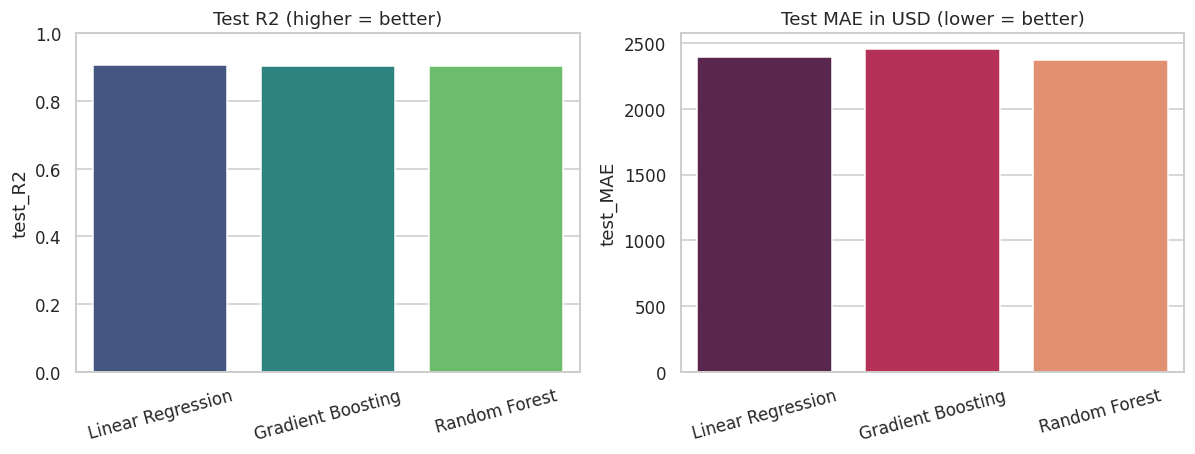

In [10]:
res = pd.DataFrame(results)
res["lift_R2_vs_baseline"] = res["test_R2"] - res.loc[0,"test_R2"]
res["MAE_reduction"]       = res.loc[0,"test_MAE"] - res["test_MAE"]
display(res.round(3))

# 圖 6：模型比較長條圖
fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.barplot(data=res, x="model", y="test_R2", palette="viridis", ax=ax[0]); ax[0].set_ylim(0,1); ax[0].set_title("Test R2 (higher = better)")
sns.barplot(data=res, x="model", y="test_MAE", palette="rocket", ax=ax[1]); ax[1].set_title("Test MAE in USD (lower = better)")
for a in ax: a.tick_params(axis="x", rotation=15); a.set_xlabel("")
plt.show()

**圖 7 / 圖 8：最佳模型的「預測 vs 實際」與殘差診斷。**

測試 R² 最高的模型: Linear Regression


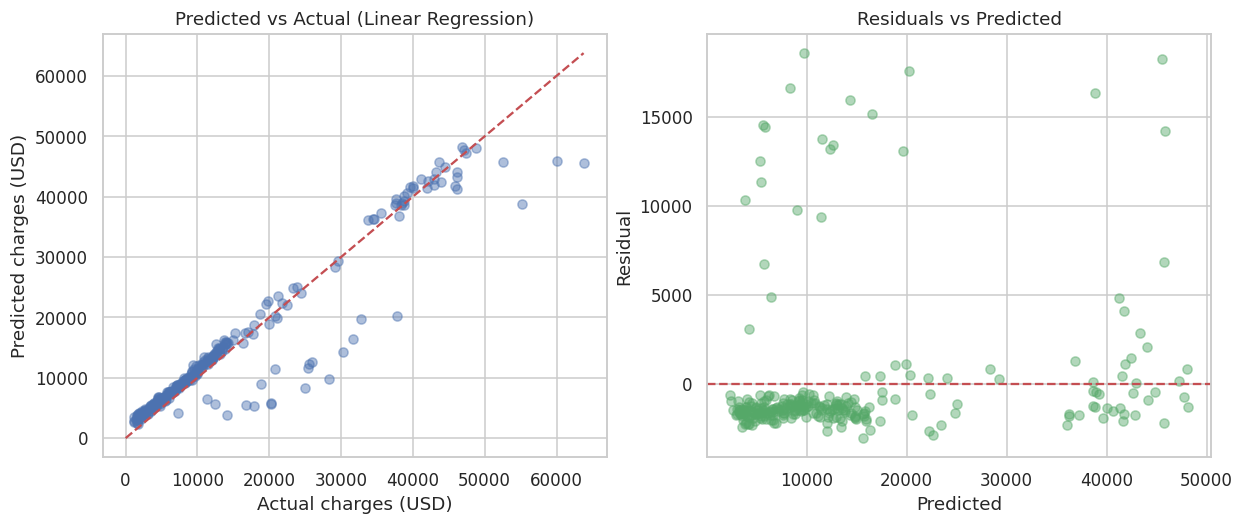

In [11]:
best_name = res.loc[res['test_R2'].idxmax(),'model']
best_pred = {"Linear Regression":pred_lin,"Gradient Boosting":pred_gbr,"Random Forest":pred_rf}[best_name]
print("測試 R² 最高的模型:", best_name)

fig, ax = plt.subplots(1,2, figsize=(13,5))
ax[0].scatter(y_test, best_pred, alpha=.45); lims=[0,max(y_test.max(),best_pred.max())]
ax[0].plot(lims, lims, "r--"); ax[0].set_title(f"Predicted vs Actual ({best_name})")
ax[0].set_xlabel("Actual charges (USD)"); ax[0].set_ylabel("Predicted charges (USD)")
resid = y_test.values - best_pred
ax[1].scatter(best_pred, resid, alpha=.45, color="#55A868"); ax[1].axhline(0, ls="--", c="r")
ax[1].set_title("Residuals vs Predicted"); ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual")
plt.show()

## 階段 5 — 結果詮釋與商業結論

**圖 9：特徵重要性（以梯度提升模型）** —— 找出最具預測力的特徵。

,feature,importance
0,smoker_obese,0.4094
1,smoker_yes,0.3878
2,age2,0.0707
3,bmi,0.0691
4,age,0.0513
5,children,0.0106
6,region_southwest,0.0007
7,sex_male,0.0003
8,region_southeast,0.0001
9,region_northwest,0.0000


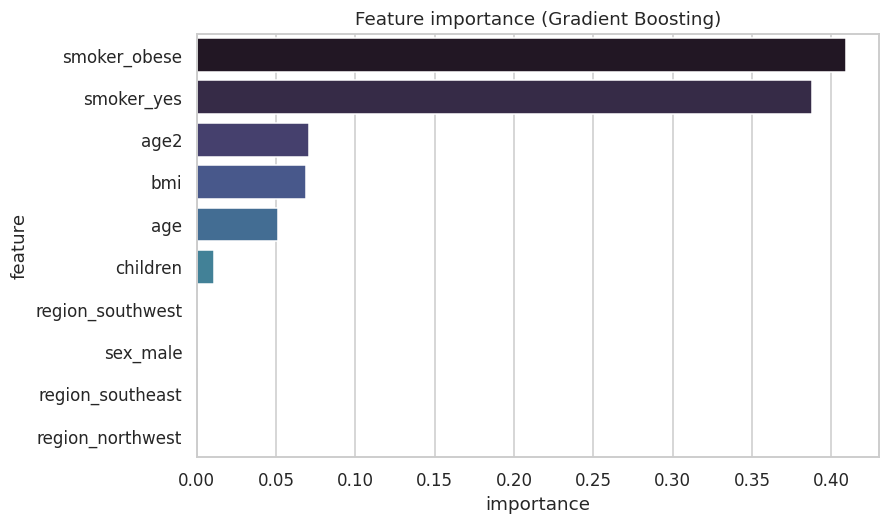

In [12]:
model = best_gbr.named_steps["model"]
cat_names = list(best_gbr.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(categorical))
imp = (pd.DataFrame({"feature": numeric + cat_names, "importance": model.feature_importances_})
       .sort_values("importance", ascending=False).reset_index(drop=True))
display(imp.round(4))
plt.figure(figsize=(8,5)); sns.barplot(data=imp.head(10), x="importance", y="feature", palette="mako")
plt.title("Feature importance (Gradient Boosting)"); plt.show()

### 商業結論與建議

**模型表現（翻成商業語言）**
- 三個模型皆能解釋約 **90% 的費用變異**（測試 R² ≈ 0.90),平均誤差約 **每人 $2,400**。
- 重要的是:加入「吸菸×肥胖」交互項與 `age²` 後,**可解釋的線性迴歸表現已與調參後的樹模型相當** ——
  這是一個「有充分理由的簡單模型勝出」的案例,在受監管的訂價情境中更為合適。

**最重要的特徵與經濟直覺**
| 排名 | 特徵 | 經濟直覺 |
|---|---|---|
| 1 | `smoker_obese` | 吸菸 + 肥胖 = 慢性病風險加乘 |
| 2 | `smoker` | 吸菸本身就是最主要的費用驅動因子 |
| 3 | `age` / `age2` | 費用隨年齡累積且加速 |
| 4 | `bmi` | BMI 越高,代謝/心血管風險越高 |
| — | `region`、`sex` | 重要性 ≈ 0,模型在這些面向上近乎中立 |

**誠實的限制說明（intellectual honesty）**
1. 去重後僅 **1,337 筆**唯一資料,樣本量有限;大額理賠（右尾）誤差較大。
2. 原始檔案的重複是真實的**外洩陷阱** —— 結果之所以可信,正因為「切分前已去重」。
3. 特徵粗略:無診斷碼、理賠歷史、收入等,準確度上限受限於資料本身。
4. 目標右偏 → 殘差具異質變異(圖 8),對極高費用者的預測較不精準。
5. `region`/`sex` 重要性近乎 0,代表模型在這些面向公平,但也對真實地區成本差異「視而不見」。

**可執行的商業建議（actionable recommendations）**
1. **風險導向的吸菸者加費,並隨 BMI 遞增** —— 最大、最站得住腳的訂價槓桿,直接源自最重要特徵。
2. **針對吸菸+肥胖族群推動健康方案**(戒菸、體重管理),此族群每人預期節省最大。
3. **正式上線採用可解釋的線性模型**(可稽核、符合監管),並以梯度提升作為挑戰者/監控模型偵測漂移。

---

### 參考文獻（Harvard style）
- Choi, M. (2018) *Medical Cost Personal Datasets*. Kaggle. 取自:
  https://www.kaggle.com/datasets/mirichoi0218/insurance (查閱日期: 2026年6月5日)。
- Lantz, B. (2019) *Machine Learning with R*. 3rd edn. Birmingham: Packt.
- Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *JMLR*, 12, pp. 2825–2830.
- Friedman, J.H. (2001) 'Greedy function approximation: a gradient boosting machine',
  *Annals of Statistics*, 29(5), pp. 1189–1232.
- James, G., Witten, D., Hastie, T. and Tibshirani, R. (2021) *An Introduction to Statistical Learning*.
  2nd edn. New York: Springer.
